# Intel Image Classification (PyTorch)

Classifying natural scene images into 6 classes: **buildings, forest, glacier, mountain, sea, street**.

I compare three approaches:
1. A custom 4-block CNN trained from scratch
2. Fine-tuned **EfficientNet-B0** (ImageNet pretrained)
3. Fine-tuned **ConvNeXt-Tiny** (ImageNet pretrained), plus an ensemble of the two pretrained models

**Environment:** Kaggle notebook, Tesla T4 GPU, PyTorch + torchvision.

In [27]:
import torch
import os
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## 1. Dataset

[Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification) (Kaggle).

- **Train:** 14,034 images, **Test:** 3,000 images
- 150×150 RGB images, 6 balanced-ish classes (2,191 to 2,512 images per class in train)

Images are resized to 224×224 and normalized with ImageNet mean/std.
Training uses light augmentation (color jitter, horizontal flip, ±10° rotation). The test set uses no augmentation.

In [29]:
train_path = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/'

for class_name in os.listdir(train_path):
    count = len(os.listdir(train_path + class_name))
    print(f"{class_name} : {count}")

mountain : 2512
street : 2382
buildings : 2191
sea : 2274
forest : 2271
glacier : 2404


In [30]:
test_path = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test/'

for class_name in os.listdir(train_path):
    count = len(os.listdir(train_path + class_name))
    print(f"{class_name} : {count}")

mountain : 2512
street : 2382
buildings : 2191
sea : 2274
forest : 2271
glacier : 2404


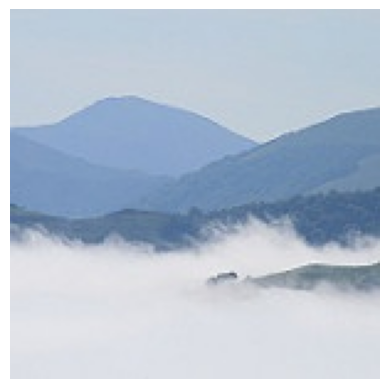

In [31]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg')
plt.imshow(img)
plt.axis('off')
plt.show()

## 2. Preprocessing and data loading

- `ToTensor()` comes before `Normalize()`, since `Normalize` works on tensors.
- Test transforms contain only resize, tensor conversion and normalization, with no random augmentation.

In [32]:
import torch
import torchvision.transforms as transforms

train_transform=transforms.Compose([transforms.Resize((224,224)),transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),transforms.RandomHorizontalFlip(p=0.5),transforms.RandomRotation(10),transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

test_transform=transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

In [33]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

train_dataset=ImageFolder(root=train_path,transform=train_transform)
test_dataset=ImageFolder(root=test_path,transform=test_transform)

train_loader=DataLoader(train_dataset, batch_size=32,shuffle=True, num_workers=2,drop_last=True)
test_loader=DataLoader(test_dataset, batch_size=32,shuffle=True, num_workers=2,drop_last=True)

## 3. Baseline: custom CNN

4 conv blocks (conv → BatchNorm → ReLU → max-pool) with channels 32 → 64 → 128 → 256,
followed by global average pooling, dropout (0.3) and a linear classifier.
Trained from scratch with Adam (lr 1e-3) and a cosine LR schedule.

In [34]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self,dropout=0.3,num_filters=32):
        super(CNN, self).__init__() 
        
        self.conv1=nn.Conv2d(3,num_filters,kernel_size=3,stride=1,padding=1)
        self.bn1=nn.BatchNorm2d(num_filters)
        self.dropout=nn.Dropout(0.1)
        
        self.conv2 =nn.Conv2d(num_filters,num_filters*2,kernel_size=3,stride=1,padding=1)
        self.bn2=nn.BatchNorm2d(num_filters*2)
        self.dropout=nn.Dropout(0.1)
        
        self.conv3=nn.Conv2d(num_filters*2,num_filters*4,kernel_size=3,stride=1,padding=1)
        self.bn3=nn.BatchNorm2d(num_filters*4)
        self.dropout=nn.Dropout(0.1)

        self.conv4=nn.Conv2d(num_filters*4,num_filters*8,kernel_size=3,stride=1,padding=1)
        self.bn4=nn.BatchNorm2d(num_filters*8)

        self.maxpool=nn.MaxPool2d(2, 2)
        self.adaptive_pool=nn.AdaptiveAvgPool2d(1)
        self.fc=nn.Linear(num_filters*8,6)
        self.dropout = nn.Dropout(dropout)

    def forward(self,x):
        x=self.maxpool(F.relu(self.bn1(self.conv1(x))))
        x=self.maxpool(F.relu(self.bn2(self.conv2(x))))
        x=self.maxpool(F.relu(self.bn3(self.conv3(x))))
        x=self.maxpool(F.relu(self.bn4(self.conv4(x))))

        x=self.adaptive_pool(x)
        x=x.view(x.size(0),-1)
        x=self.dropout(x)
        x=self.fc(x)
        return x

In [35]:
model=CNN(dropout=0.3,num_filters=32)
print(model)
model=model.to(device)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=1)
  (fc): Linear(in_features=256, out_features=6, bias=True)
)


In [36]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=50)
num_iterations=50

for epoch in range(num_iterations):
    model.train()
    current_loss=0
    correct=0
    total=0

    for image,labels in train_loader:
        image = image.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs=model(image)
        loss=criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        
        current_loss+=loss.item()
        probas,predicted=outputs.max(1)
        total+=labels.size(0)
        correct+=(labels==predicted).sum()
    scheduler.step()    

    train_accuracy=(correct/total)*100
    train_loss=current_loss/len(train_loader)
    print(f"epoch {epoch} train_accuracy {train_accuracy} train_loss {train_loss}")

'import torch.optim as optim\n\ncriterion = nn.CrossEntropyLoss()\noptimizer = optim.Adam(model.parameters(), lr=0.001)\nscheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=50)\nnum_iterations=50\n\nfor epoch in range(num_iterations):\n    model.train()\n    current_loss=0\n    correct=0\n    total=0\n\n    for image,labels in train_loader:\n        image = image.to(device)\n        labels = labels.to(device)\n\n        optimizer.zero_grad()\n        outputs=model(image)\n        loss=criterion(outputs,labels)\n        loss.backward()\n        optimizer.step()\n        \n        current_loss+=loss.item()\n        probas,predicted=outputs.max(1)\n        total+=labels.size(0)\n        correct+=(labels==predicted).sum()\n    scheduler.step()    \n\n    train_accuracy=(correct/total)*100\n    train_loss=current_loss/len(train_loader)\n    print(f"epoch {epoch} train_accuracy {train_accuracy} train_loss {train_loss}")'

### Loading model weights directly

In [37]:
torch.save(model.state_dict(),"/kaggle/working/CNNscratch_intel.pth")

In [38]:
import os, zipfile

src="/kaggle/input/models/saichaithanyiap/cnn-scratch/pytorch/default/1/CNNscratch_intel"
out="/kaggle/working/CNNscratch_intel.pth"

with zipfile.ZipFile(out, "w", zipfile.ZIP_STORED) as z:
    for root, _, files in os.walk(src):
        for f in files:
            full = os.path.join(root,f)
            rel = os.path.relpath(full,src)
            z.write(full, os.path.join("archive",rel)) 

model=CNN(dropout=0.3,num_filters=32)
model.load_state_dict(torch.load(out,map_location=device))
model=model.to(device)
model.eval()

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=1)
  (fc): Linear(in_features=256, out_features=6, bias=True)
)

In [39]:
for name, param in model.named_parameters():
    print(name, param.shape)

conv1.weight torch.Size([32, 3, 3, 3])
conv1.bias torch.Size([32])
bn1.weight torch.Size([32])
bn1.bias torch.Size([32])
conv2.weight torch.Size([64, 32, 3, 3])
conv2.bias torch.Size([64])
bn2.weight torch.Size([64])
bn2.bias torch.Size([64])
conv3.weight torch.Size([128, 64, 3, 3])
conv3.bias torch.Size([128])
bn3.weight torch.Size([128])
bn3.bias torch.Size([128])
conv4.weight torch.Size([256, 128, 3, 3])
conv4.bias torch.Size([256])
bn4.weight torch.Size([256])
bn4.bias torch.Size([256])
fc.weight torch.Size([6, 256])
fc.bias torch.Size([6])


### Model Evaluation

In [40]:
model.eval()

val_correct=0
val_total=0

with torch.no_grad():
    for images,labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        output=model(images)
        _,predicted=output.max(1)
        val_total+=labels.size(0)
        val_correct+=(labels==predicted).sum()
        
val_accuracy=(val_correct/val_total)*100
print(val_accuracy)

tensor(89.0121, device='cuda:0')


## 4. Transfer learning: EfficientNet-B0

Loaded ImageNet weights and replaced the final layer (`classifier[1]`) with a 6-class linear layer.
All layers were fine-tuned with a small learning rate.

In [41]:
from torchvision.models import efficientnet_b0,EfficientNet_B0_Weights
import torch.nn as nn

model2=efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
model2.classifier[1]=nn.Linear(model2.classifier[1].in_features,6)
model2=model2.to(device)

In [42]:
import os, zipfile

src="/kaggle/input/models/saichaithanyiap/efficientnet-b0/pytorch/default/1/efficientnetb0_intel"
out="/kaggle/working/efficientnetb0_intel.pth"

with zipfile.ZipFile(out, "w", zipfile.ZIP_STORED) as z:
    for root, _, files in os.walk(src):
        for f in files:
            full = os.path.join(root,f)
            rel = os.path.relpath(full,src)
            z.write(full, os.path.join("archive",rel)) 

model2=efficientnet_b0(weights=None) 
model2.classifier[1]=nn.Linear(model2.classifier[1].in_features, 6)
model2.load_state_dict(torch.load(out, map_location=device))
model2=model2.to(device)
model2.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [43]:
from torch import optim

for p in model2.parameters():
    p.requires_grad=True
model2.classifier[1] = nn.Linear(model2.classifier[1].in_features,6)
model2=model2.to(device)
optimizer=optim.AdamW(model2.parameters(),lr=5e-5,weight_decay=0.05)
criterion=nn.CrossEntropyLoss()
scheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=3)
scaler=torch.amp.GradScaler("cuda")

for epoch in range(3):
    model2.train()
    for x,y in train_loader:
        x,y=x.to(device,non_blocking=True),y.to(device,non_blocking=True)
        optimizer.zero_grad()
        with torch.autocast("cuda", dtype=torch.float16):
            loss=criterion(model3(x), y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
    scheduler.step()    
    print("epoch", epoch, "done")

'from torch import optim\n\nfor p in model2.parameters():\n    p.requires_grad=True\nmodel2.classifier[1] = nn.Linear(model2.classifier[1].in_features,6)\nmodel2=model2.to(device)\noptimizer=optim.AdamW(model2.parameters(),lr=5e-5,weight_decay=0.05)\ncriterion=nn.CrossEntropyLoss()\nscheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=3)\nscaler=torch.amp.GradScaler("cuda")\n\nfor epoch in range(3):\n    model2.train()\n    for x,y in train_loader:\n        x,y=x.to(device,non_blocking=True),y.to(device,non_blocking=True)\n        optimizer.zero_grad()\n        with torch.autocast("cuda", dtype=torch.float16):\n            loss=criterion(model3(x), y)\n        scaler.scale(loss).backward()\n        scaler.step(optimizer)\n        scaler.update()\n    scheduler.step()    \n    print("epoch", epoch, "done")'

In [44]:
torch.save(model2.state_dict(),"/kaggle/working/efficientnetb0_intel.pth")

#### Model Evaluation

In [45]:
model2.eval()

val_correct2=0
val_total2=0

with torch.no_grad():
    for images,labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        output=model2(images)
        _,predicted=output.max(1)
        val_total2+=labels.size(0)
        val_correct2+=(labels==predicted).sum()
        
val_accuracy2=(val_correct2/val_total2)*100
print(val_accuracy2)

tensor(94.2204, device='cuda:0')


## 5. Transfer learning: ConvNeXt-Tiny

Replaced the head (`classifier[2]`) with a 6-class linear layer and fine-tuned all layers.

- Optimizer: AdamW (lr 5e-5, weight decay 0.05), cosine schedule, 4 epochs
- Mixed precision (`torch.autocast` + `GradScaler`) to speed up training on the T4

In [46]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
model3=convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
model3.classifier[2]=nn.Linear(model3.classifier[2].in_features, 6)

In [47]:
from torch import optim

for p in model3.parameters():
    p.requires_grad=True
model3.classifier[2] = nn.Linear(model3.classifier[2].in_features,6)
model3=model3.to(device)
optimizer=optim.AdamW(model3.parameters(),lr=5e-5,weight_decay=0.05)
criterion=nn.CrossEntropyLoss()
scheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=4)
scaler=torch.amp.GradScaler("cuda")

for epoch in range(4):
    model3.train()
    for x,y in train_loader:
        x,y=x.to(device,non_blocking=True),y.to(device,non_blocking=True)
        optimizer.zero_grad()
        with torch.autocast("cuda", dtype=torch.float16):
            loss=criterion(model3(x), y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
    scheduler.step()    
    print("epoch", epoch, "done")

'from torch import optim\n\nfor p in model3.parameters():\n    p.requires_grad=True\nmodel3.classifier[2] = nn.Linear(model3.classifier[2].in_features,6)\nmodel3=model3.to(device)\noptimizer=optim.AdamW(model3.parameters(),lr=5e-5,weight_decay=0.05)\ncriterion=nn.CrossEntropyLoss()\nscheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=4)\nscaler=torch.amp.GradScaler("cuda")\n\nfor epoch in range(4):\n    model3.train()\n    for x,y in train_loader:\n        x,y=x.to(device,non_blocking=True),y.to(device,non_blocking=True)\n        optimizer.zero_grad()\n        with torch.autocast("cuda", dtype=torch.float16):\n            loss=criterion(model3(x), y)\n        scaler.scale(loss).backward()\n        scaler.step(optimizer)\n        scaler.update()\n    scheduler.step()    \n    print("epoch", epoch, "done")'

#### Loading saved model weights and states

In [48]:
model3=convnext_tiny(weights=None) 
model3.classifier[2]=nn.Linear(model3.classifier[2].in_features, 6)
model3.load_state_dict(torch.load("/kaggle/input/models/saichaithanyiap/convnext-tiny/pytorch/default/1/convnexttiny_intel (3).pth", map_location=device))
model3=model3.to(device)

#### Model Evaluation

In [49]:
model3.eval()

val_correct3=0
val_total3=0

with torch.no_grad():
    for images,labels in test_loader:
        images=images.to(device)
        labels=labels.to(device)
        output=model3(images)
        _,predicted=output.max(1)
        val_total3+=labels.size(0)
        val_correct3+=(labels==predicted).sum()
        
val_accuracy3=(val_correct3/val_total3)*100
print(val_accuracy3)

tensor(95.1949, device='cuda:0')


In [50]:
torch.save(model3.state_dict(),"/kaggle/working/convnexttiny_intel.pth")

## 6. Ensemble and test-time augmentation (TTA)

- **Ensemble:** weighted average of the softmax probabilities of EfficientNet-B0 and ConvNeXt-Tiny.
- **TTA:** averaged predictions over 8 views (original, flip, center crop, corner crops).

I compared each setting with and without TTA.

In [51]:
import torch
import torch.nn.functional as F

def make_views(x,crop=0.875):
    B,C,H,W=x.shape
    ch,cw=int(H*crop),int(W*crop)

    def crop_resize(t,top,left):
        t=t[:,:,top:top+ch,left:left+cw]
        return F.interpolate(t,size=(H,W),mode="bilinear",align_corners=False)

    views=[x,torch.flip(x,dims=[3])]  

    center=crop_resize(x,(H-ch)//2,(W-cw)//2)
    views+=[center,torch.flip(center,dims=[3])]

    for top,left in [(0,0),(0,W-cw),(H-ch,0),(H-ch,W-cw)]:
        views.append(crop_resize(x,top,left))      
    return views                     

def predict_tta(m,x,crop=0.875):
    views=make_views(x,crop)
    probs=sum(F.softmax(m(v),dim=1) for v in views)
    return probs/len(views)

In [52]:
cnn=model
eff=model2
tiny=model3

cnn.eval()
eff.eval()
tiny.eval()

def ensembling(loader,w=0.5):
    correct=total=0
    with torch.no_grad():
        for x,y in loader:
            x,y=x.to(device),y.to(device)
            p1=F.softmax(tiny(x),dim=1)
            p2=F.softmax(eff(x),dim=1)
            p=predict_tta(tiny,x)+(1-w)*predict_tta(eff,x)
            correct+=(p.argmax(1)==y).sum().item()
            total+=y.size(0)
    return correct/total

tuned the weight to find that weight=0.3 for eff and 0.7 for tiny gives the pest

In [54]:
def ensembling(loader, w=0.5, tta=True):
    cnn.eval(); eff.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if tta:
                p1, p2 = predict_tta(eff, x), predict_tta(tiny, x)
            else:
                p1, p2 = F.softmax(eff(x),1),F.softmax(tiny(x),1)
            p = w * p1 + (1 - w) * p2
            correct+=(p.argmax(1) == y).sum().item()
            total+=y.size(0)
    return 100*correct/total

print(0.3,"no TTA:",round(ensembling(test_loader,0.3,tta=False), 2),"| TTA:",round(ensembling(test_loader,0.3,tta=True),2))

0.1 no TTA: 95.36 | TTA: 94.99


## 7. Results

| Model | Test accuracy |
|---|---|
| Custom CNN (from scratch) | 89.08% |
| EfficientNet-B0 (fine-tuned) | 94.19% |
| ConvNeXt-Tiny (fine-tuned) | 95.19% |
| Ensemble (EfficientNet 0.3 + ConvNeXt 0.7) | 95.36% |

**Observations**
- Transfer learning gave about +5 points over the scratch CNN.
- ConvNeXt-Tiny was the best single model.
- The ensemble added only about +0.3 points, which is within the noise of a 3,000-image test set (roughly ±0.4%).
- Crop-based TTA did **not** help (it was slightly worse in every setting), so the final setup uses no TTA.

  ## 8. Error analysis

  Per-class results and the confusion matrix for ConvNeXt-Tiny are shown below.

  - Most errors are **glacier ↔ mountain**: 42 glaciers predicted as mountain and 36 mountains predicted as glacier.
  - Next are **buildings ↔ street** (21 and 14) and glacier → sea (11).
  - Forest and sea are almost perfect (recall 0.99 and 1.00).
  - Some of these images are ambiguous or arguably mislabeled, which limits the achievable accuracy.

In [55]:
from sklearn.metrics import confusion_matrix,classification_report
preds,labels=[],[]
tiny.eval()
with torch.no_grad():
   for x,y in DataLoader(test_dataset,batch_size=64,shuffle=False):
       preds+=tiny(x.to(device)).argmax(1).cpu().tolist()
       labels+=y.tolist()
print(classification_report(labels,preds,target_names=test_dataset.classes))
print(confusion_matrix(labels,preds))

              precision    recall  f1-score   support

   buildings       0.97      0.95      0.96       437
      forest       1.00      0.99      0.99       474
     glacier       0.93      0.90      0.91       553
    mountain       0.92      0.92      0.92       525
         sea       0.96      1.00      0.98       510
      street       0.95      0.97      0.96       501

    accuracy                           0.95      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.95      0.95      0.95      3000

[[414   0   0   1   1  21]
 [  0 470   3   0   0   1]
 [  0   0 498  42  11   2]
 [  0   1  36 481   6   1]
 [  0   0   1   0 508   1]
 [ 14   0   0   0   1 486]]


## 9. Limitations and notes

- The ensemble weight was chosen using the test set, so the ensemble figure is slightly optimistic. The single-model ConvNeXt number (95.19%) is the cleaner headline.
- No separate validation split was used. A future version should tune on validation data and evaluate on the test set once.
- Published results for this dataset are in the ~95-96% range, so remaining gains are small.

## 10. Possible next steps

- Hold out a validation set and tune hyperparameters on it
- Try a larger model (ConvNeXt-Small, EfficientNet-B2)
- Serve the model as an API (FastAPI) with weights in S3